In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [ ]:
md = pd.read_csv("data/metadata_boxplot_data_all_figureS7_ptype_Sep2026.csv")
md.shape

# Pol II occupancy filter - the single criterion used for every dxChIP-seq panel.
#
# Genes are included where untreated cells show Pol II at the promoter, defined as
# TSS coverage more than 1.41-fold of mean upstream background,
# i.e. log2(TSS / upstream) > 0.5. The column ``TSS_cov_D8L4Y_0h`` is that value
# divided by the mean upstream signal, so the cutoff is applied directly as a fold.
MIN_TSS_FOLD = (
    2**0.5
)  # log2(TSS / upstream) > 0.5; 0.32 RPKM at the 0 h background of 0.2262

n_before = len(md)
md = md[md["TSS_cov_D8L4Y_0h"].notna() & (md["TSS_cov_D8L4Y_0h"] > MIN_TSS_FOLD)]
print(
    f"occupancy filter (log2 fold > 0.5, i.e. > {MIN_TSS_FOLD:.3f}x background): {n_before} -> {len(md)} genes"
)

occupancy filter (log2 fold > 0.5, i.e. > 1.414x background): 9860 -> 9307 genes


In [4]:
# No expression re-filter here. The gene set was already selected upstream
# (log2(TSS coverage / mean upstream coverage) > 0.5 at 0 h) when this table was built.
print(f"Genes in table: {md.gene_id.nunique():,}")
print("TSS log2FC available:     ", md["TSS_log2FC_90min_0h"].notna().sum())
print("Gene body log2FC available:", md["GeneBody_log2FC_90min_0h"].notna().sum())

Genes in table: 9,307
TSS log2FC available:      9307
Gene body log2FC available: 8516


In [5]:
# Long format: one row per gene x region x timepoint
lfc = (
    md.melt(
        id_vars="gene_id",
        value_vars=[
            "TSS_log2FC_90min_0h",
            "TSS_log2FC_8h_0h",
            "GeneBody_log2FC_90min_0h",
            "GeneBody_log2FC_8h_0h",
        ],
        var_name="column",
        value_name="log2FC",
    )
    .assign(
        region=lambda x: np.where(x.column.str.startswith("TSS"), "TSS", "Gene Body"),
        condition=lambda x: np.where(x.column.str.contains("90min"), "1.5 h", "8 h"),
    )
    .drop(columns="column")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["log2FC"])
)
lfc.groupby(["condition", "region"]).size()

condition  region   
1.5 h      Gene Body    8516
           TSS          9307
8 h        Gene Body    8516
           TSS          9307
dtype: int64

In [6]:
threshold = 0.5  # log2FC threshold

for condition in ["1.5 h", "8 h"]:
    for region in ["TSS", "Gene Body"]:
        subset = lfc[(lfc["condition"] == condition) & (lfc["region"] == region)]
        n_total = len(subset)
        n_stable = (subset["log2FC"].abs() < threshold).sum()
        print(
            f"{condition}, {region}: "
            f"{n_stable}/{n_total} genes have |log2FC| < {threshold}  ->  {n_stable / n_total:.1%}"
        )

1.5 h, TSS: 8798/9307 genes have |log2FC| < 0.5  ->  94.5%
1.5 h, Gene Body: 8449/8516 genes have |log2FC| < 0.5  ->  99.2%
8 h, TSS: 8868/9307 genes have |log2FC| < 0.5  ->  95.3%
8 h, Gene Body: 8408/8516 genes have |log2FC| < 0.5  ->  98.7%


In [ ]:
# Genes falling outside the plotted x-range, so the axis limits below are a deliberate
# choice rather than a silent truncation.
for condition in ["1.5 h", "8 h"]:
    for region in ["TSS", "Gene Body"]:
        s = lfc[(lfc["condition"] == condition) & (lfc["region"] == region)]
        print(
            f"{condition}, {region}: {(s.log2FC.abs() > 1).sum()} genes outside [-1, 1]"
        )

1.5 h, TSS: 12 genes outside [-1, 1]
1.5 h, Gene Body: 1 genes outside [-1, 1]
8 h, TSS: 3 genes outside [-1, 1]
8 h, Gene Body: 3 genes outside [-1, 1]


In [8]:
short_plot = lfc[lfc["condition"] == "1.5 h"]
long_plot = lfc[lfc["condition"] == "8 h"]

binwidth = 0.02

lo = np.floor(lfc.log2FC.min() / binwidth) * binwidth
hi = np.ceil(lfc.log2FC.max() / binwidth) * binwidth
bin_edges = np.arange(lo, hi + binwidth / 2, binwidth)

ymax = max(
    np.histogram(g.log2FC, bins=bin_edges)[0].max()
    for _, g in lfc.groupby(["condition", "region"])
)
ymax = int(np.ceil(ymax * 1.05 / 10) * 10)
print("y-limit:", ymax)

y-limit: 740


/var/folders/bk/jfxwkhls69b5qm00y25gv6200000gp/T/ipykernel_18857/1159276611.py:7: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.histplot(


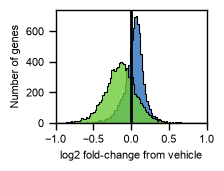

In [9]:
sns.set_context("paper")

f, a = plt.subplots(figsize=(3, 1.8))

pal = sns.color_palette(["xkcd:apple", "xkcd:medium blue", "grey"])

sns.histplot(
    data=short_plot,
    x="log2FC",
    hue="region",
    edgecolor="black",
    palette=pal,
    bins=bin_edges,
    alpha=0.8,
    element="step",
    legend=False,
    ax=a,
)

a.set_box_aspect(0.75)
a.set_xlim(-1, 1)
a.set_ylim(0, ymax)
a.axvline(0, color="black", linewidth=2)
a.set_ylabel("Number of genes", fontsize=8)
a.set_xlabel("log2 fold-change from vehicle", fontsize=8)
a.tick_params(axis="both", labelsize=8)
f.tight_layout()

f.savefig("0_vs_90min_TSSgreen_GBblue.svg")

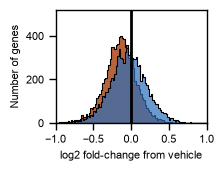

In [14]:
sns.set_context("paper")

f, a = plt.subplots(figsize=(3, 1.8))

sns.histplot(
    data=short_plot.query('region == "TSS"'),
    x="log2FC",
    color="xkcd:rust",
    edgecolor="black",
    bins=bin_edges,
    element="step",
    alpha=0.8,
    legend=False,
    ax=a,
)

sns.histplot(
    data=long_plot.query('region == "TSS"'),
    x="log2FC",
    color="xkcd:medium blue",
    edgecolor="black",
    bins=bin_edges,
    element="step",
    alpha=0.7,
    legend=False,
    ax=a,
)

a.set_box_aspect(0.75)
a.set_xlim(-1, 1)
a.set_ylim(0, 520)
a.axvline(0, color="black", linewidth=2)
a.set_ylabel("Number of genes", fontsize=8)
a.set_xlabel("log2 fold-change from vehicle", fontsize=8)
a.tick_params(axis="both", labelsize=8)
f.tight_layout()

f.savefig("0_vs_90min_rust_8hour_blue_TSS.svg")

In [ ]:
# Fold change of summed coverage - weights by expression level
for region, tss_col, gb_col in [
    ("TSS", "TSS_cov_D8L4Y_0h", "TSS_cov_D8L4Y_90min"),
    ("Gene Body", "GeneBody_cov_D8L4Y_0h", "GeneBody_cov_D8L4Y_90min"),
]:
    sub = md[[tss_col, gb_col]].dropna()
    total_0h, total_1_5h = sub[tss_col].sum(), sub[gb_col].sum()
    print(f"\n{region}:")
    print(f"  Total coverage at 0h:   {total_0h:.1f}")
    print(f"  Total coverage at 1.5h: {total_1_5h:.1f}")
    print(f"  Fold change (summed):   {total_1_5h / total_0h:.4f}")


TSS:
  Total coverage at 0h:   53023.5
  Total coverage at 1.5h: 48167.6
  Fold change (summed):   0.9084

Gene Body:
  Total coverage at 0h:   9716.8
  Total coverage at 1.5h: 9767.9
  Fold change (summed):   1.0053


In [ ]:
# Marginal scatter of TSS vs gene-body occupancy, one panel per condition
conditions = {"0 h": "D8L4Y_0h", "1.5 h": "D8L4Y_90min", "8 h": "D8L4Y_8h"}
colors = {"0 h": "grey", "1.5 h": "xkcd:rust", "8 h": "xkcd:medium blue"}

panels = {}
for label, suffix in conditions.items():
    df = md[[f"TSS_cov_{suffix}", f"GeneBody_cov_{suffix}"]].dropna()
    df = df[(df > 0).all(axis=1)]
    panels[label] = pd.DataFrame(
        {
            "log2_TSS": np.log2(df[f"TSS_cov_{suffix}"]),
            "log2_GB": np.log2(df[f"GeneBody_cov_{suffix}"]),
        }
    )

print({k: len(v) for k, v in panels.items()})

{'0 h': 8516, '1.5 h': 8516, '8 h': 8516}


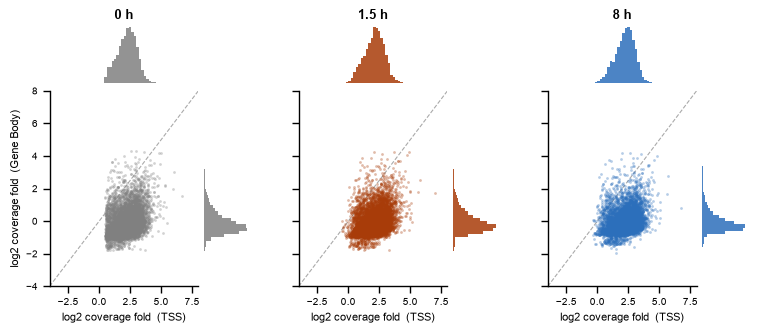

In [ ]:
lims = (-4, 8)
fig = plt.figure(figsize=(9, 3.4))
outer_gs = fig.add_gridspec(1, 3, wspace=0.25)

for col_idx, (cond, df) in enumerate(panels.items()):
    color = colors[cond]
    inner_gs = outer_gs[col_idx].subgridspec(
        2, 2, width_ratios=[4, 1.2], height_ratios=[1.2, 4], hspace=0.06, wspace=0.06
    )
    ax_scatter = fig.add_subplot(inner_gs[1, 0])
    ax_top_hist = fig.add_subplot(inner_gs[0, 0], sharex=ax_scatter)
    ax_rgt_hist = fig.add_subplot(inner_gs[1, 1], sharey=ax_scatter)

    ax_scatter.scatter(
        df["log2_TSS"],
        df["log2_GB"],
        s=4,
        alpha=0.35,
        color=color,
        linewidths=0,
        rasterized=True,
    )
    ax_scatter.plot(lims, lims, lw=0.8, ls="--", color="#aaaaaa", zorder=0)
    ax_scatter.set_xlim(lims)
    ax_scatter.set_ylim(lims)
    ax_scatter.set_xlabel("log2 coverage fold  (TSS)", fontsize=8)
    if col_idx == 0:
        ax_scatter.set_ylabel("log2 coverage fold  (Gene Body)", fontsize=8)
    else:
        ax_scatter.tick_params(labelleft=False)
    ax_scatter.tick_params(axis="both", labelsize=7)
    for sp in ["top", "right"]:
        ax_scatter.spines[sp].set_visible(False)

    ax_top_hist.hist(
        df["log2_TSS"], bins=60, range=lims, color=color, alpha=0.85, linewidth=0
    )
    ax_top_hist.set_title(cond, fontsize=9, fontweight="bold", pad=4)
    ax_top_hist.axis("off")

    ax_rgt_hist.hist(
        df["log2_GB"],
        bins=60,
        range=lims,
        color=color,
        alpha=0.85,
        linewidth=0,
        orientation="horizontal",
    )
    ax_rgt_hist.axis("off")

fig.savefig("PolII_coverage_marginal_scatter.png", dpi=300, bbox_inches="tight")
fig.savefig("PolII_coverage_marginal_scatter.svg", bbox_inches="tight")